In [ ]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from itertools import product
from scipy.stats import boxcox, probplot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)
from scipy.special import inv_boxcox
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam

# Ignore warnings
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Set plot parameter
plt.rcParams['figure.figsize'] = (14, 6)

# Ensuring reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
data = "https://raw.githubusercontent.com/faadeola/oil_prices_ts_analysis/refs/heads/main/oil_prices_2426.csv"

oil_df = pd.read_csv(data, parse_dates=['date'])
oil_df.set_index('date', inplace=True)
oil_df.sort_index(inplace=True)

# Set the frequency to daily
oil_df.index.freq = 'D'

# Rename price column
oil_df.rename(columns={'price (dollars)': 'price'}, inplace=True)

# Print shape and range of data
print(f"Dataset shape  : {oil_df.shape} \n")
print(f"Date range     : {oil_df.index.min()} ------ {oil_df.index.max()} \n")
print(f"Missing Values: {oil_df.isnull().sum()}")

Dataset shape  : (500, 1) 

Date range     : 2024-09-21 00:00:00 ------ 2026-02-02 00:00:00 

Missing Values: price    0
dtype: int64


In [ ]:
# Preview data
oil_df.head()

,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [ ]:
# Display data info
oil_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-09-21 to 2026-02-02
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB


In [ ]:
# Summary statistics
oil_df.describe().round(2)

,price
count,500.00
mean,75.87
std,42.91
min,16.48
25%,35.37
50%,64.29
75%,111.57
max,158.78


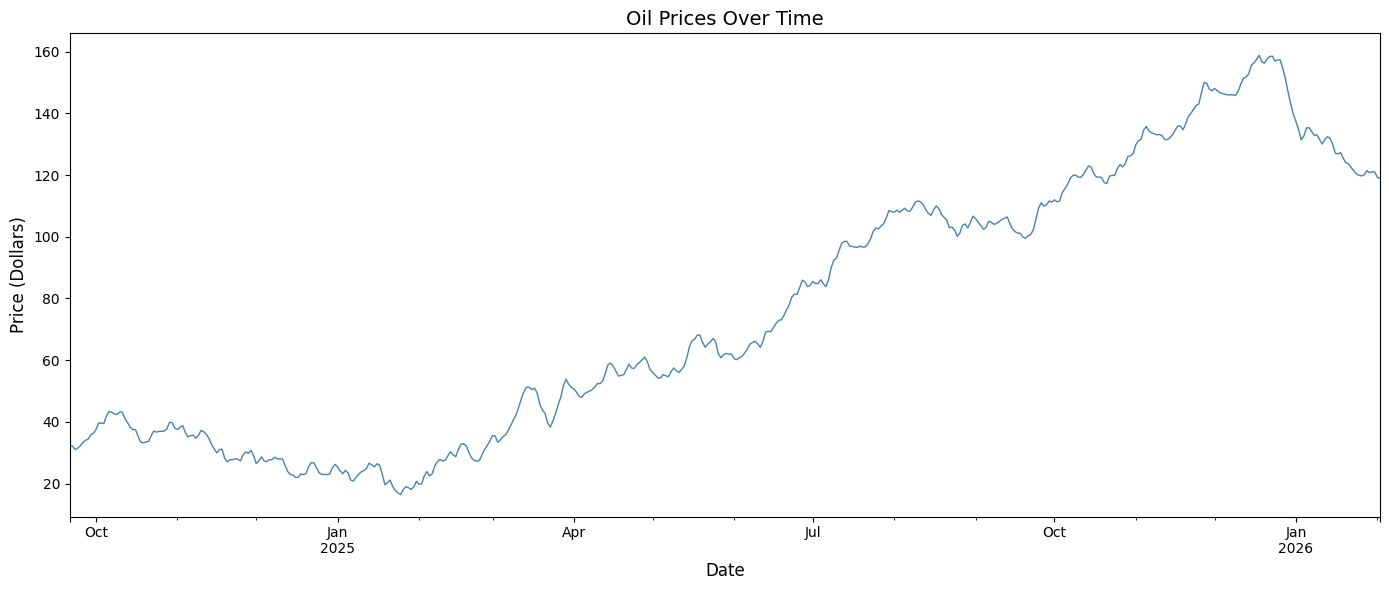

In [ ]:
# Plot time series plot
fig, ax = plt.subplots(figsize=(14,6))
oil_df['price'].plot(color='steelblue', linewidth=1)
plt.title('Oil Prices Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (Dollars)', fontsize=12)
plt.tight_layout()
plt.show()

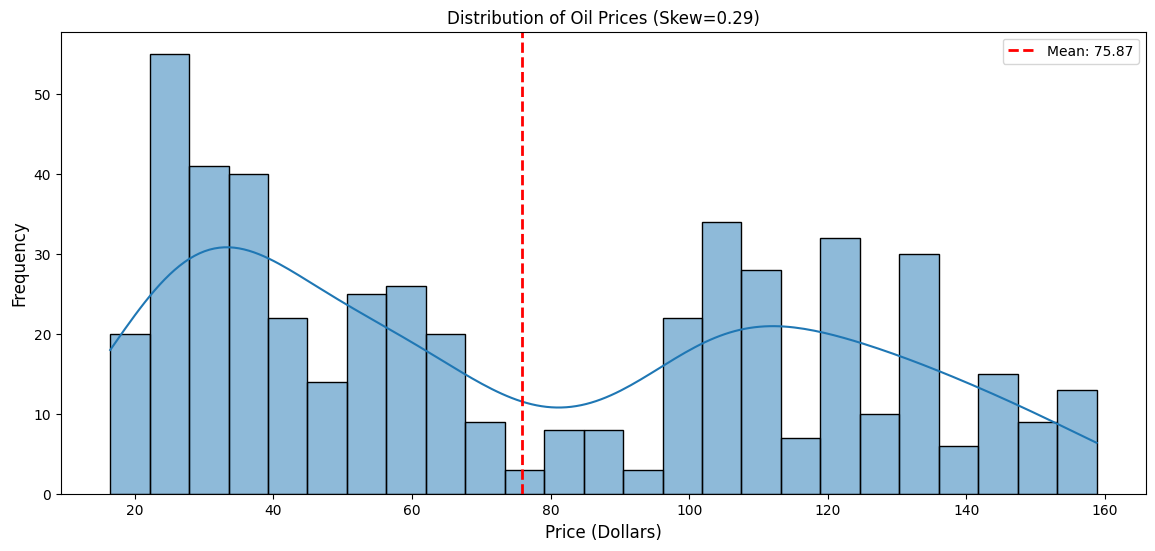

In [ ]:
# Plot distribution of oil prices
plt.figure(figsize=(14, 6))
sns.histplot(oil_df["price"], bins=25, kde=True)
plt.axvline(
    oil_df["price"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {oil_df['price'].mean():.2f}"
)
plt.title(f"Distribution of Oil Prices (Skew={oil_df['price'].skew():.2f})")
plt.xlabel("Price (Dollars)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.ylabel("Frequency")
plt.legend(loc="best")
plt.show()

In [ ]:
# Extract year and month from the date index
oil_df["month_name"] = oil_df.index.strftime("%B")
oil_df["year"] = oil_df.index.strftime("%Y")

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

# Monthly average across all years
monthly_avg = oil_df.groupby("month_name")["price"].mean().round(2).reindex(month_order)
print("Monthly Average Oil Prices:")
print(monthly_avg)
print()

# Yearly average
yearly_avg = oil_df.groupby("year")["price"].mean().round(2)
print("Yearly Average Oil Prices:")
print(yearly_avg)
print()

# Monthly average per year
monthly_yearly_avg = (
    oil_df.pivot_table(
        values="price", index="month_name", columns="year", aggfunc="mean", fill_value=0
    )
    .round(2)
    .reindex(month_order)
)
print("Monthly Average per Year:")
monthly_yearly_avg

Monthly Average Oil Prices:
month_name
January       74.76
February      33.99
March         43.90
April         54.82
May           60.83
June          71.76
July          95.94
August       106.92
September     86.92
October       79.12
November      84.81
December      88.36
Name: price, dtype: float64

Yearly Average Oil Prices:
year
2024     32.23
2025     83.44
2026    127.09
Name: price, dtype: float64

Monthly Average per Year:


year,2024,2025,2026
month_name,,,
January,0.00,21.92,127.61
February,0.00,27.92,119.08
March,0.00,43.90,0.00
April,0.00,54.82,0.00
May,0.00,60.83,0.00
June,0.00,71.76,0.00
July,0.00,95.94,0.00
August,0.00,106.92,0.00
September,33.32,104.79,0.00


In [ ]:
# Function for getting the metrics of each model
def evaluate_model(actual, predicted, model_name="Model"):

    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = np.round(mean_absolute_error(actual, predicted), 2)
    rmse = np.round(np.sqrt(mean_squared_error(actual, predicted)), 2)
    mape = np.round(mean_absolute_percentage_error(actual, predicted) * 100, 2)

    print(f"{'='*35}")
    print(f"{model_name} Performance:")
    print(f"MAE  : {mae}")
    print(f"RMSE : {rmse}")
    print(f"MAPE : {mape}%")
    print(f"{'='*35}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
# Split data into training and test
train_size = int(len(oil_df) * 0.8)

train = oil_df.iloc[:train_size].copy()
test = oil_df.iloc[train_size:].copy()

In [ ]:
# Transform the data using Box-Cox transformation to stabilize variance
train['price_transformed'], lambda_ = boxcox(train['price'])

# Print lambda
print('Lambda: %f' % lambda_)

Lambda: 0.030242


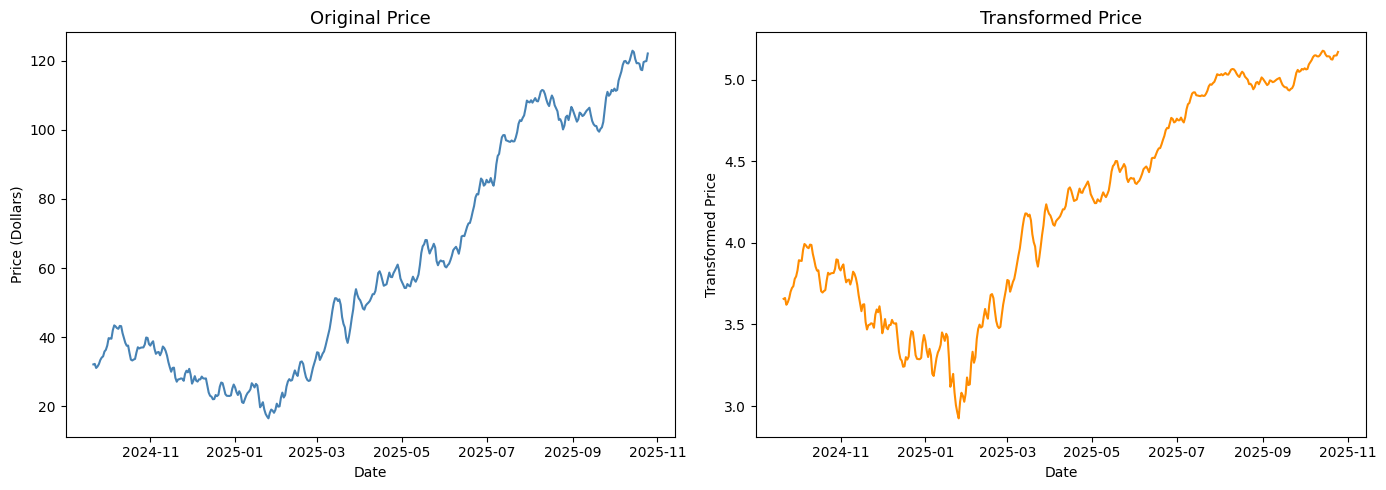

In [ ]:
# Plot the transformed data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train['price'], color='steelblue')
axes[0].set_title('Original Price', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (Dollars)')

axes[1].plot(train['price_transformed'], color='darkorange')
axes[1].set_title('Transformed Price', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Transformed Price')

plt.tight_layout()
plt.show()

In [ ]:
# Function to Plot ACF and PACF plots
def plot_acf_pacf(series, lag_value, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    plot_acf(series, ax=axes[0], lags=lag_value)
    plot_pacf(series, ax=axes[1], lags=lag_value)

    # Set titles and labels for ACF plots
    axes[0].set_title(f'{title} - Autocorrelation (ACF)', fontsize=14)
    axes[0].set_xlabel('Lag, k', fontsize=12)
    axes[0].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[0].grid(True, which='major', linestyle='--', alpha=0.2)

    # Set titles and labels for PACF plots
    axes[1].set_title(f'{title} - Partial Autocorrelation (PACF)', fontsize=14)
    axes[1].set_xlabel('Lag, k', fontsize=12)
    axes[1].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[1].grid(True, which='major', linestyle='--', alpha=0.2)

    plt.tight_layout()
    plt.show()

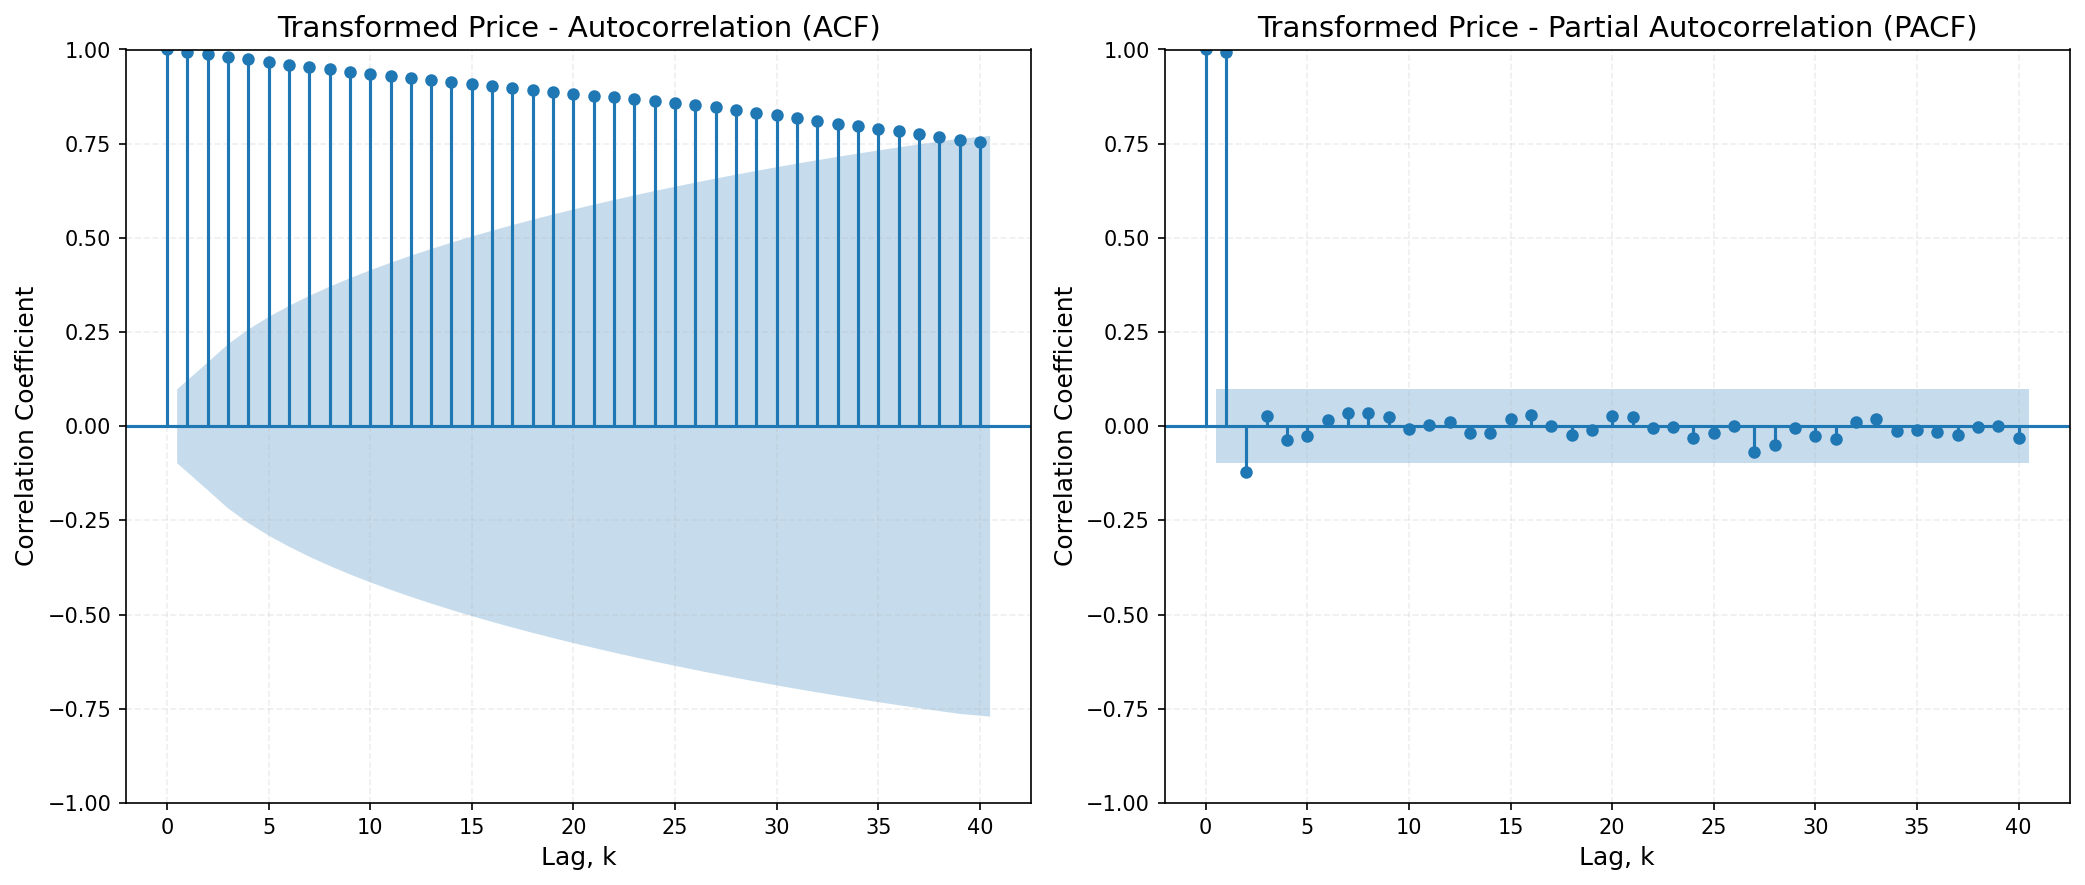

In [ ]:
# Plot the ACF and PACF so we can assess the correlations in the data (lags) and see if it looks stationary
plot_acf_pacf(train['price_transformed'], 40, 'Transformed Price')

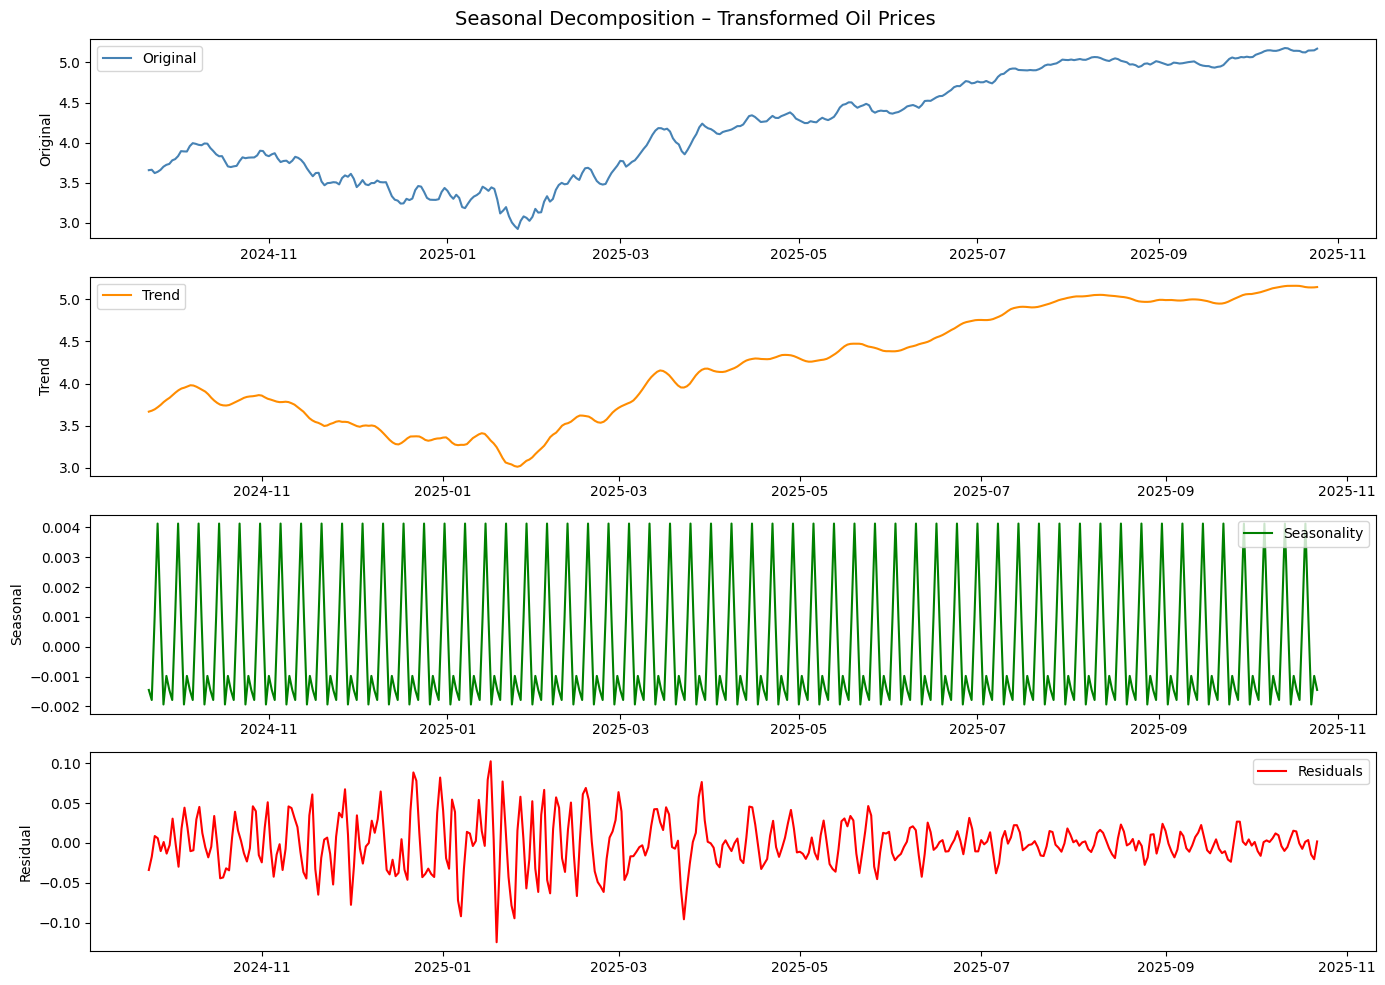

In [ ]:
# build seasonal decomposition model
decomposition = seasonal_decompose(train['price_transformed'], model='additive')

# Plot the decomposition results
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(train['price_transformed'], label='Original', color='steelblue')
axes[0].legend(loc='best')
axes[0].set_ylabel('Original')

axes[1].plot(trend, label='Trend', color='darkorange')
axes[1].legend(loc='best')
axes[1].set_ylabel('Trend')

axes[2].plot(seasonal, label='Seasonality', color='green')
axes[2].legend(loc='best')
axes[2].set_ylabel('Seasonal')

axes[3].plot(residual, label='Residuals', color='red')
axes[3].legend(loc='best')
axes[3].set_ylabel('Residual')

plt.suptitle('Seasonal Decomposition – Transformed Oil Prices', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
"""Use the Augmented Dickey-Fuller test and KPSS test to check for stationarity"""


# ADF Test function
def stationarity_test(series, label):

    print(f"{'='*50}")
    print(f"  Stationarity Tests: {label}")
    print(f"{'='*50}")

    # ADF Test
    adf_result = adfuller(series.dropna())
    print("Augmented Dickey-Fuller Test Results:")
    print(f"ADF Statistic: {adf_result[0]:.2f}")
    print(f"p-value: {adf_result[1]:.2f}")
    print("Critical Values:")
    for key, value in adf_result[4].items():
        print(f"\t{key}: {value:.2f}")

    if adf_result[1] < 0.05:
        print(f"Time series is stationary (reject null hypothesis)")
    else:
        print(f"Time series is non-stationary (fail to reject null hypothesis)")

    print('\n')

    # KPSS Test function
    kpss_result = kpss(series.dropna(), regression="c")
    print("KPSS Test Results:")
    print(f"KPSS Statistic: {kpss_result[0]:.2f}")
    print(f"p-value: {kpss_result[1]:.2f}")

    if kpss_result[1] > 0.05:
        print(f"Time series is stationary (reject null hypothesis)")
    else:
        print(f"Time series is non-stationary (fail to reject null hypothesis)")

In [ ]:
# Perform the ADF and KPSS tests to check for stationarity
stationarity_test(train["price_transformed"], "")

  Stationarity Tests: 
Augmented Dickey-Fuller Test Results:
ADF Statistic: 0.20
p-value: 0.97
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57
Time series is non-stationary (fail to reject null hypothesis)


KPSS Test Results:
KPSS Statistic: 2.76
p-value: 0.01
Time series is non-stationary (fail to reject null hypothesis)


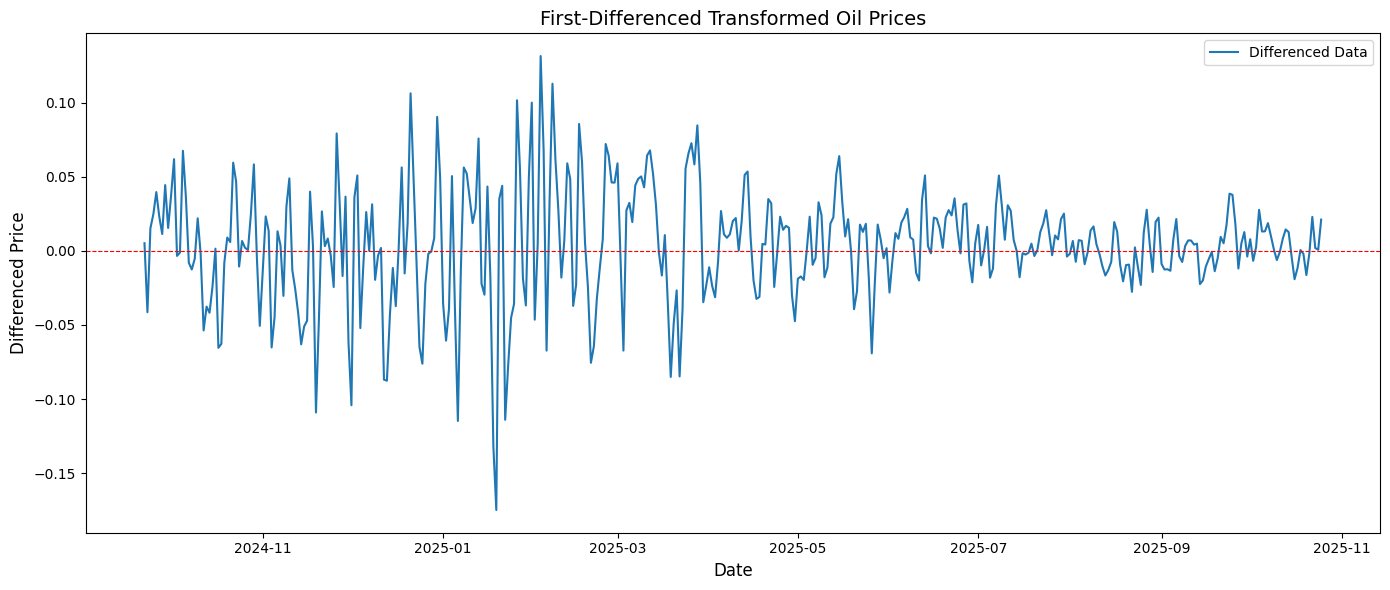

In [ ]:
# Difference the data to make it stationary
train['price_diff'] = train['price_transformed'].diff()

# Plot the differenced data
plt.figure(figsize=(14, 6))
plt.plot(train['price_diff'], label='Differenced Data')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.title('First-Differenced Transformed Oil Prices', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Differenced Price', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Perform the ADF and KPSS tests on the differenced series
stationarity_test(train['price_diff'], 'Differenced Price')

  Stationarity Tests: Differenced Price
Augmented Dickey-Fuller Test Results:
ADF Statistic: -5.74
p-value: 0.00
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57
Time series is stationary (reject null hypothesis)


KPSS Test Results:
KPSS Statistic: 0.16
p-value: 0.10
Time series is stationary (reject null hypothesis)


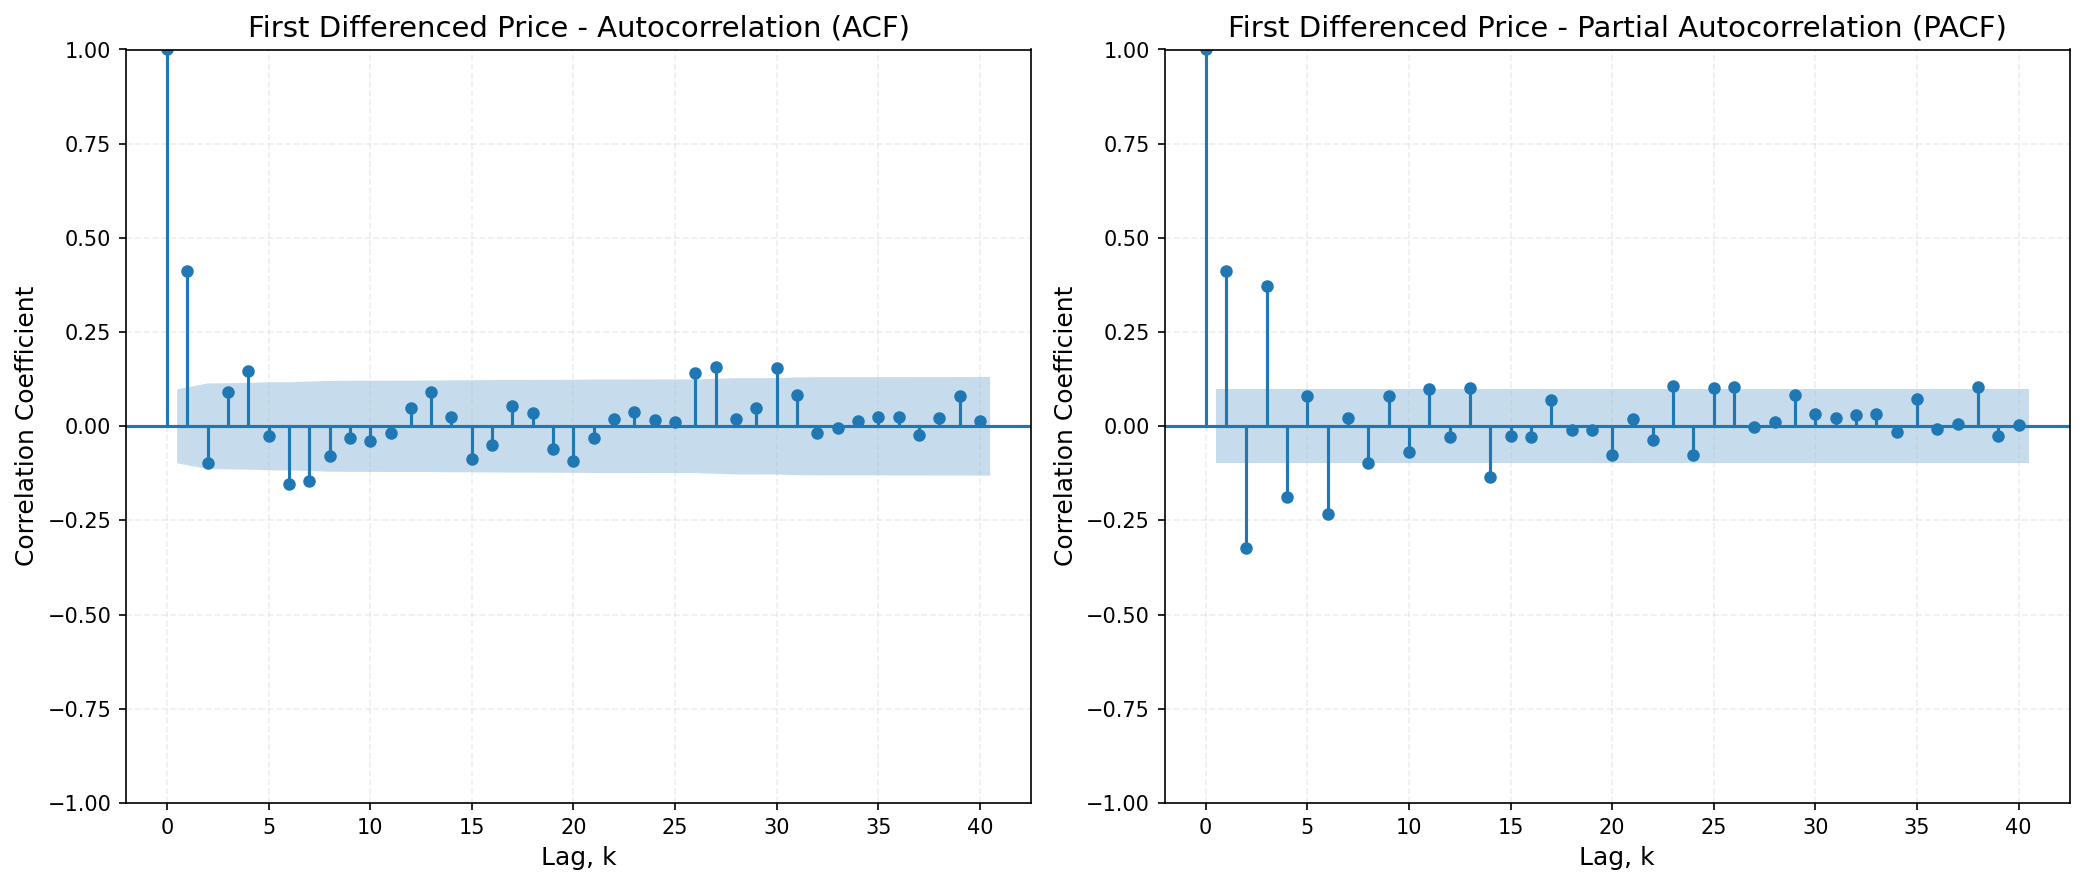

In [ ]:
# Plot the ACF and PACF of the differenced series to identify candidate p and q values for ARIMA(p,d,q)
plot_acf_pacf(train['price_diff'].dropna(), 40, 'First Differenced Price')

# BUILDING ARIMA MODEL
This section focuses on working with arma/arima model for time series forecasting

In [ ]:
# Define the ARIMA model with the identified order (p, d, q)
model = ARIMA(train['price_transformed'], order=(4, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      price_transformed   No. Observations:                  400
Model:                 ARIMA(4, 1, 1)   Log Likelihood                 862.569
Date:                Wed, 11 Mar 2026   AIC                          -1713.137
Time:                        23:01:34   BIC                          -1689.203
Sample:                    09-21-2024   HQIC                         -1703.658
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0673      0.039     -1.743      0.081      -0.143       0.008
ar.L2         -0.0848      0.042     -2.005      0.045      -0.168      -0.002
ar.L3          0.0774      0.042      1.843      0.0

In [ ]:
# Find the best ARIMA model using AIC criteria
def find_best_arima_model(series, max_p, max_d, max_q):
    best_aic, best_order_aic = float("inf"), None
    model_order, aic_value = [], []
    num_of_combinations = 0  # Counter for number of combinations evaluated

    # Loop through all combinations of p, d, q and fit the ARIMA model
    for d in range(0, max_d + 1):
        for p in range(0, max_p + 1):
            for q in range(0, max_q + 1):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    model_fit = model.fit()
                    aic = model_fit.aic
                    model_order.append((p, d, q))
                    aic_value.append(aic)
                    num_of_combinations += 1

                    if aic < best_aic:
                        best_aic = aic
                        best_order_aic = (p, d, q)

                except Exception as e:
                    continue

    # Create a DataFrame to display the results and sort by AIC and BIC
    model_search_df = (
        pd.DataFrame({"Model Order": model_order, "AIC": aic_value})
        .sort_values(by="AIC", ascending=True)
        .reset_index(drop=True)
    )

    # Print number of combinations evaluated
    print(f"{num_of_combinations} combinations evaluated.")

    # Return the results for subsequent analysis
    return model_search_df, best_order_aic, best_aic

In [ ]:
# Search for the best ARIMA model with p, d, q values
model_search_df, best_order_aic, best_aic = find_best_arima_model(train['price_transformed'], max_p=8, max_d=2, max_q=8)

#Print the best ARIMA model based on AIC
print(f'Best ARIMA model based on AIC: ARIMA{best_order_aic} with AIC={best_aic:.2f}')

243 combinations evaluated.
Best ARIMA model based on AIC: ARIMA(4, 1, 3) with AIC=-1717.21


In [ ]:
# Print first 5 rows of the model search results
model_search_df.head()

,Model Order,AIC
0,"(4, 1, 3)",-1717.205956
1,"(2, 1, 5)",-1716.916616
2,"(2, 1, 6)",-1716.874297
3,"(5, 1, 3)",-1716.651723
4,"(2, 1, 3)",-1716.584900


In [ ]:
# Fit model on training data and Print the summary of the best ARIMA model
best_model_order = model_search_df.loc[0, 'Model Order']
best_arima_model = ARIMA(train['price_transformed'], order=best_model_order).fit()
print(best_arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:      price_transformed   No. Observations:                  400
Model:                 ARIMA(4, 1, 3)   Log Likelihood                 866.603
Date:                Wed, 11 Mar 2026   AIC                          -1717.206
Time:                        23:06:50   BIC                          -1685.294
Sample:                    09-21-2024   HQIC                         -1704.567
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1765      0.103     11.445      0.000       0.975       1.378
ar.L2         -0.8191      0.110     -7.454      0.000      -1.034      -0.604
ar.L3          0.2030      0.068      3.003      0.0

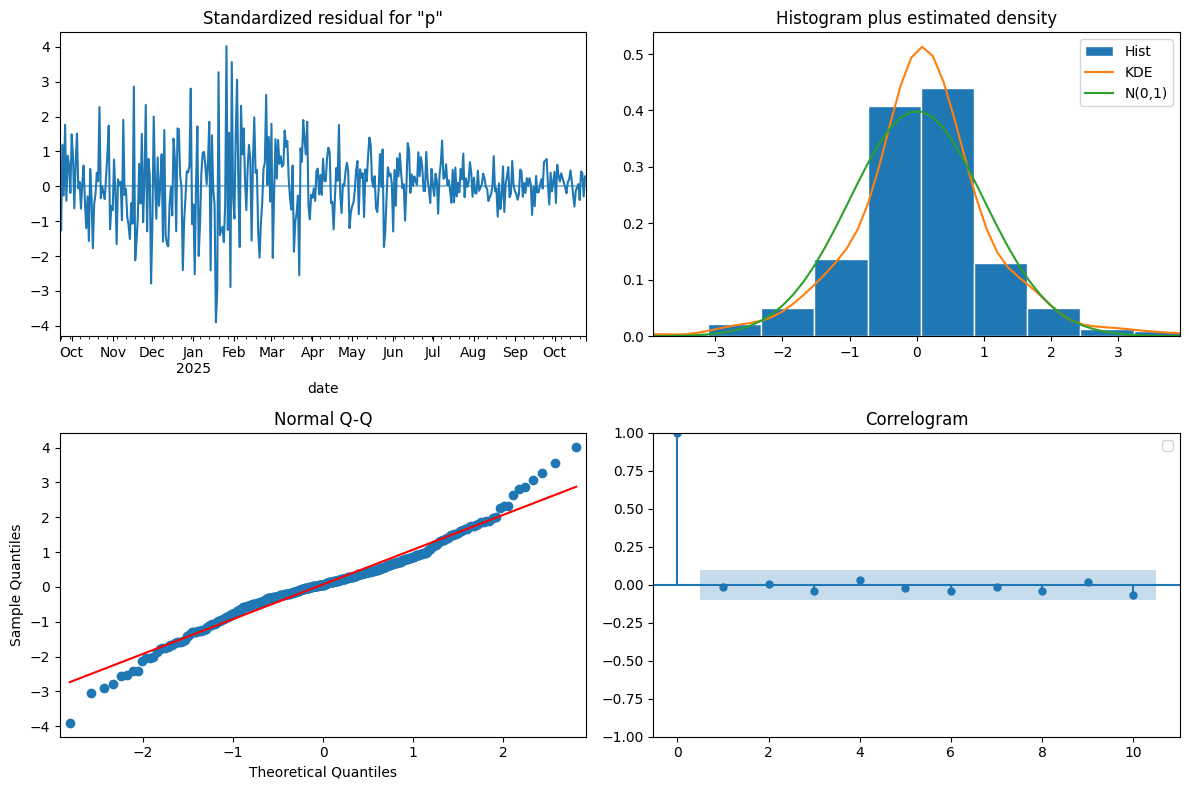

In [ ]:
# Residual analysis for the best ARIMA model
best_arima_model.plot_diagnostics(figsize=(12, 8))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
"""Fit and predict using the best ARIMA model on test set"""

# Test predictions
test_predictions = best_arima_model.predict(start=len(train), end=len(train) + len(test) - 1)
test_predictions.index = test.index
test_pred_inv = inv_boxcox(test_predictions, lambda_)
test_actual = test["price"]

# Train predictions
train_predictions = best_arima_model.fittedvalues
train_pred_inv = inv_boxcox(train_predictions, lambda_)
train_actual = train["price"]

# Evaluate train and test sets
train_metrics = evaluate_model(train_actual, train_pred_inv, model_name="ARIMA – Train")
test_metrics = evaluate_model(test_actual, test_pred_inv, model_name="ARIMA – Test")

residuals = test_actual - test_pred_inv

ARIMA – Train Performance:
MAE  : 0.86
RMSE : 1.84
MAPE : 2.01%
ARIMA – Test Performance:
MAE  : 15.31
RMSE : 18.83
MAPE : 10.55%


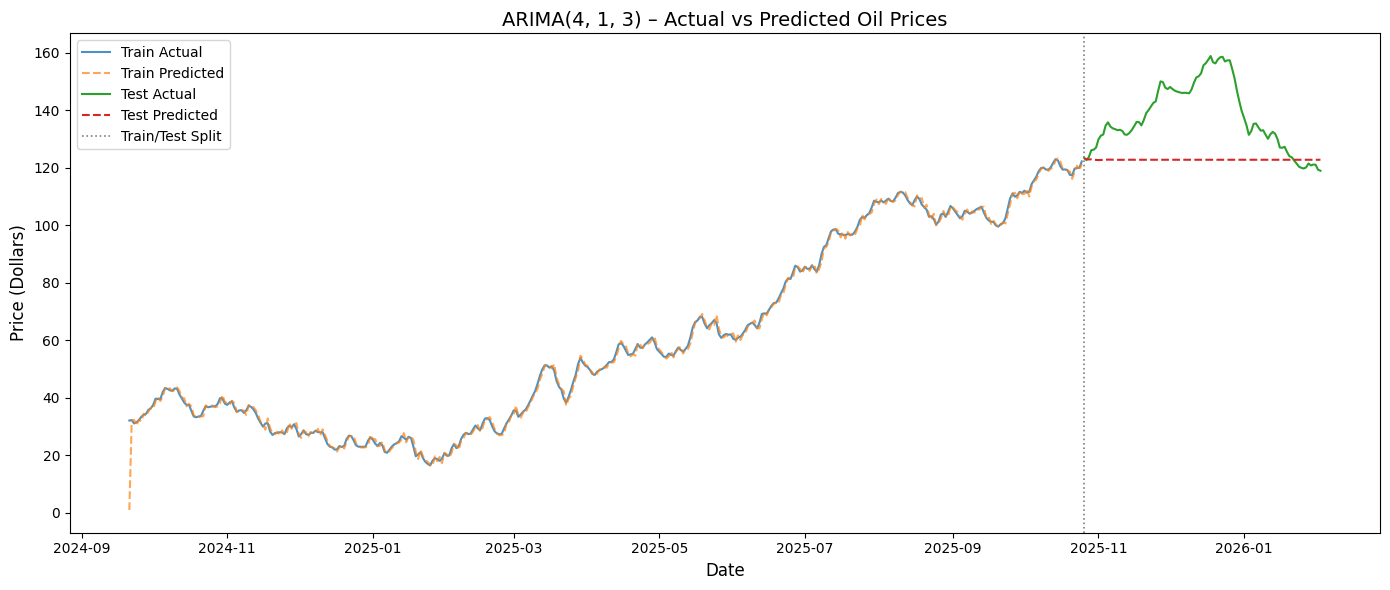

In [ ]:
# Plot the graph for the Arimal Model
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_actual, label='Train Actual', alpha=0.8)
ax.plot(train_pred_inv, label='Train Predicted', linestyle='--', alpha=0.7)
ax.plot(test_actual, label='Test Actual')
ax.plot(test_pred_inv, label='Test Predicted',  linestyle='--')
ax.axvline(x=test.index[0], color='grey', linestyle=':', linewidth=1.2, label='Train/Test Split')
ax.set_title(f'ARIMA{best_model_order} – Actual vs Predicted Oil Prices', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (Dollars)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Get the root mean squared error and mean absolute error of the residuals
print(f'Root Mean Squared Error (RMSE): {np.sqrt(np.mean(residuals**2)):.2f}')

Root Mean Squared Error (RMSE): 18.83


## Forecasting with Best Arima Model
Using the .get_forecast() method

In [ ]:
"""
Make the predictions for 24 months ahead
Using the .get_forecast method
"""

# Transform the data using Box-Cox transformation to stabilize variance
oil_df["price_transformed"] = boxcox(oil_df["price"], lmbda=lambda_)

# 24 months ahead (assuming 30 days in a month)
steps = 730

# Fit model on final full series
final_model = ARIMA(oil_df["price_transformed"], order=best_model_order).fit()

predictions_int = final_model.get_forecast(steps=steps)

predicted_mean = pd.Series(predictions_int.predicted_mean)
conf_int = predictions_int.conf_int()

predicted_mean = inv_boxcox(predicted_mean, lambda_)
conf_int = inv_boxcox(conf_int, lambda_)

# Get the predicted daily values and confidence intervals
daily_forecast = predicted_mean.round(2)
daily_forecast_ci = conf_int.round(2)

In [ ]:
# convert daily forecast to monthly by resampling
monthly_forecast_arima = daily_forecast.resample('MS').mean()
monthly_forecast_arima_ci = daily_forecast_ci.resample('MS').mean()

In [ ]:
# Generate confidence intervals data for the forecasted predictions
conf_df = pd.concat([monthly_forecast_arima, monthly_forecast_arima_ci], axis=1)
conf_df.columns = ["Predicted Mean", "Lower CI", "Upper CI"]

# Display the forecasted predictions and confidence intervals
conf_df.head(10)

,Predicted Mean,Lower CI,Upper CI
2026-02-01,118.460769,90.224615,156.747692
2026-03-01,118.470968,69.813226,200.024516
2026-04-01,118.470000,58.636333,236.291667
2026-05-01,118.470000,51.024839,269.723226
2026-06-01,118.470000,45.265000,302.037000
2026-07-01,118.470000,40.680968,333.926129
2026-08-01,118.470000,36.846774,366.291613
2026-09-01,118.470000,33.668333,398.315333
2026-10-01,118.470000,30.943226,430.673226
2026-11-01,118.470000,28.570667,463.468333


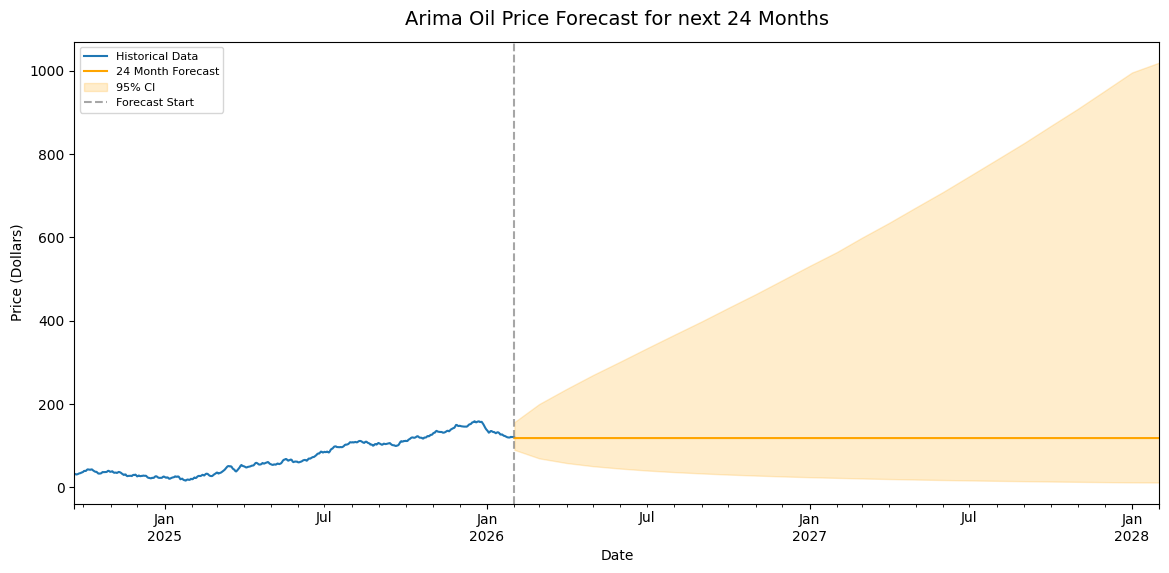

In [ ]:
# plot historical data, forecasted predictions and confidence intervals
fig, ax = plt.subplots(figsize=(14, 6))
oil_df["price"].plot(ax=ax, label="Historical Data")
monthly_forecast_arima.plot(ax=ax, label="24 Month Forecast", color="orange")
plt.fill_between(
    conf_df.index,
    conf_df["Lower CI"],
    conf_df["Upper CI"],
    color="orange",
    alpha=0.2,
    label="95% CI",
)

plt.axvline(
    monthly_forecast_arima.index[0],
    color="grey",
    linestyle="--",
    label="Forecast Start",
    alpha=0.7,
)
plt.xlabel("Date")
plt.ylabel("Price (Dollars)")
plt.title("Arima Oil Price Forecast for next 24 Months", fontsize=14, pad=12)
plt.legend(loc="best", fontsize=8)
plt.show()

# Long Short Term Memory (LSTM) Model

In [ ]:
# Set actual column for this model
original_df = oil_df['price'].values.astype(float)

In [ ]:
"""
Multiple functions created
to act as data transformations
"""


def difference(dataset, interval=1):
    """Create a differenced series to achieve stationarity."""
    diff = []
    for i in range(interval, len(dataset)):
        diff.append(dataset[i] - dataset[i - interval])
    return pd.Series(diff)


def inverse_difference(history, yhat, interval=1):
    """To invert a differenced forecast value back to original scale."""
    return yhat + history[-interval]


def timeseries_to_supervised(data, lag=1):
    """
    Frame a univariate time series as a supervised learning problem.
    """
    data_df = pd.DataFrame(data)
    columns = [data_df.shift(i) for i in range(1, lag + 1)]
    columns.append(data_df)
    data_df = pd.concat(columns, axis=1)
    data_df.fillna(0, inplace=True)
    return data_df


def scale(train, test):
    """
    Fit MinMaxScaler on train, transform both splits to [-1, 1]
    """
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    train_scaled = scaler.transform(train.reshape(train.shape[0], train.shape[1]))
    test_scaled = scaler.transform(test.reshape(test.shape[0], test.shape[1]))
    return scaler, train_scaled, test_scaled


def invert_scale(scaler, X, value):
    """Reconstruct a full row and inverse-transform to recover the target value."""
    new_row = np.array(list(X) + [value]).reshape(1, -1)
    return scaler.inverse_transform(new_row)[0, -1]

In [ ]:
def fit_lstm(train, nb_epoch, neurons, dropout=0.2, learning_rate=0.001):
    '''
    Fit a 2-layer LSTM.
    Walk-forward validation handles sequential evaluation after training.
    '''
    X, y = train[:, 0:-1], train[:, -1]

    # (samples, timesteps=1, features=lag)
    X = X.reshape(X.shape[0], 1, X.shape[1])

    # Create model layers
    model = Sequential()
    model.add(
        LSTM(
            neurons,
            input_shape=(X.shape[1], X.shape[2]),
            stateful=False,
            recurrent_dropout=dropout,
            return_sequences=True,
        )
    )
    model.add(Dropout(dropout))
    model.add(LSTM(max(neurons // 2, 8), recurrent_dropout=dropout))
    model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(loss='mse', optimizer=Adam(learning_rate=learning_rate))

    # EarlyStopping on training loss prevents overfitting.
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

    # Fit model
    model.fit(
        X, y, epochs=nb_epoch, batch_size=16, verbose=0, shuffle=False, callbacks=[early_stop]
    )

    return model


def forecast_lstm(model, X):
    '''One-step forecast. Reshapes X to (1, 1, lag) for prediction.'''
    X = X.reshape(1, 1, len(X))
    return model.predict(
        X,
        batch_size=1,
        verbose=0,
    )[0, 0]


def feed_model(model, train_scaled):
    '''
    Feed training data through the model to build hidden state before
    walk-forward validation begins.
    '''
    X_feed = train_scaled[:, 0:-1].reshape(len(train_scaled), 1, -1)
    model.predict(X_feed, batch_size=len(X_feed), verbose=0)

def walk_forward_validation(model, test_scaled, history, scaler):
    predictions = []

    for i in range(len(test_scaled)):
        X = test_scaled[i, 0:-1]

        yhat = forecast_lstm(model, X)
        yhat = invert_scale(scaler, X, yhat)

        yhat = history[-1] + yhat
        history.append(yhat)

        predictions.append(yhat)

    return predictions

In [ ]:
# Differencing removes trend so the LSTM learns price changes, not price levels.
diff_values = difference(original_df, interval=1)

In [ ]:
def find_best_lag(diff_values, original_df, lag_values=None):
    """
    Test lightweight LSTMs across candidate lag values.
    Uses a quick 50-epoch run with neurons=16 to rank lags by test RMSE.
    """
    if lag_values is None:
        lag_values = [7, 14, 30, 60, 90]

    results = {}
    for lag in lag_values:
        supervised = timeseries_to_supervised(diff_values, lag)
        supervised_vals = supervised.values
        split = int(len(supervised_vals) * 0.8)
        train, test = supervised_vals[:split], supervised_vals[split:]
        scaler, train_scaled_data, test_scaled_data = scale(train, test)

        model = fit_lstm(
            train_scaled_data, nb_epoch=50, neurons=16, dropout=0.1, learning_rate=0.001
        )

        history = list(original_df[:-len(test_scaled_data)])
        preds = walk_forward_validation(model, test_scaled_data, history, scaler)
        actual = original_df[-len(test_scaled_data) :]
        rmse = np.sqrt(mean_squared_error(actual, preds))
        results[lag] = rmse
        print(f"  Lag = {lag}  |  RMSE = {rmse:.4f}")

    best_lag = min(results, key=results.get)
    print(f"Best lag: {best_lag}  (RMSE: {results[best_lag]:.4f})\n")

    # Plot chart of the lags and their rmse score
    plt.figure(figsize=(7, 4))
    plt.bar([str(k) for k in results.keys()], results.values(), color="steelblue")
    plt.xlabel("Lag (days)")
    plt.ylabel("Test RMSE")
    plt.title("RMSE by Lag Value")
    plt.tight_layout()
    plt.show()

    return best_lag, results

  Lag = 14  |  RMSE = 9.5537
  Lag = 30  |  RMSE = 10.4557
  Lag = 60  |  RMSE = 10.6440
  Lag = 90  |  RMSE = 12.0136
  Lag = 120  |  RMSE = 14.0911
Best lag: 14  (RMSE: 9.5537)



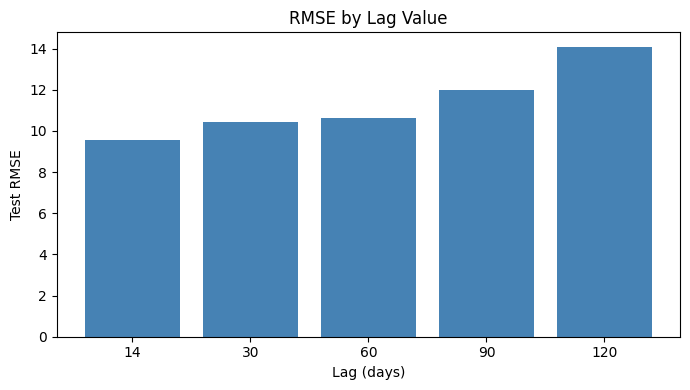

In [ ]:
# Find best lag value for actual model fitting
best_lag, lag_results = find_best_lag(
    diff_values, original_df, lag_values=[14, 30, 60, 90, 120]
)

In [ ]:
# Frame with best lag, then 80/20 split, then scale
supervised = timeseries_to_supervised(diff_values, best_lag)
supervised_vals = supervised.values

# Split training and testing data
split = int(len(supervised_vals) * 0.8)
train, test = supervised_vals[:split], supervised_vals[split:]

# Scale train and test data
scaler, train_scaled, test_scaled = scale(train, test)

In [ ]:
# Print out lag, train/test samples and feature shape
print(f'Lag            : {best_lag}')
print(f'Train samples  : {len(train_scaled)}')
print(f'Test  samples  : {len(test_scaled)}')
print(f'Feature shape  : (samples=1, timesteps=1, features={best_lag})')

Lag            : 14
Train samples  : 399
Test  samples  : 100
Feature shape  : (samples=1, timesteps=1, features=14)


In [ ]:
def lstm_grid_search(train_scaled, test_scaled, original_df, scaler, param_grid, n_repeats=3):
    """
    Grid search over hyperparameters. Each configuration is repeated n_repeats
    times to account for LSTM sensitivity to weight initialisation.
    Best config is chosen by mean test RMSE across repeats.
    """
    best_rmse = np.inf
    best_config = None
    all_results = []

    total = len(list(ParameterGrid(param_grid)))
    print(
        f"Testing {total} combinations × {n_repeats} repeats = "
        f"{total * n_repeats} runs\n"
    )

    for idx, config in enumerate(ParameterGrid(param_grid), 1):
        run_rmses = []
        for _ in range(n_repeats):
            model = fit_lstm(
                train_scaled,
                nb_epoch=config["epochs"],
                neurons=config["neurons"],
                dropout=config["dropout"],
                learning_rate=config["learning_rate"],
            )
            feed_model(model, train_scaled)
            history = list(original_df[:-len(test_scaled)])
            preds = walk_forward_validation(model, test_scaled, history, scaler)
            actual = original_df[-len(test_scaled) :]
            run_rmses.append(np.sqrt(mean_squared_error(actual, preds)))

        mean_rmse = np.mean(run_rmses)
        all_results.append({**config, "mean_rmse": mean_rmse})

        print(
            f"[{idx}/{total}] neurons={config['neurons']}  "
            f"dropout={config['dropout']}  lr={config['learning_rate']}  "
            f"epochs={config['epochs']}  "
            f"mean RMSE={mean_rmse:.4f}"
        )

        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_config = config

    print(f"Best config: {best_config}")
    print(f"Mean RMSE  : {best_rmse:.4f}")

    return best_config, all_results

In [ ]:
# Define parameters to search across
param_grid = {
    "neurons": [32, 50, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0001],
    "epochs": [30, 40, 50],
}

# Extract best parameter combination found
best_config, search_results = lstm_grid_search(
    train_scaled, test_scaled, original_df, scaler, param_grid, n_repeats=3
)

Testing 36 combinations × 3 repeats = 108 runs

[1/36] neurons=32  dropout=0.1  lr=0.001  epochs=30  mean RMSE=10.0781
[2/36] neurons=50  dropout=0.1  lr=0.001  epochs=30  mean RMSE=10.0638
[3/36] neurons=64  dropout=0.1  lr=0.001  epochs=30  mean RMSE=10.0263
[4/36] neurons=32  dropout=0.1  lr=0.0001  epochs=30  mean RMSE=14.0898
[5/36] neurons=50  dropout=0.1  lr=0.0001  epochs=30  mean RMSE=13.2988
[6/36] neurons=64  dropout=0.1  lr=0.0001  epochs=30  mean RMSE=12.8164
[7/36] neurons=32  dropout=0.1  lr=0.001  epochs=40  mean RMSE=9.8035
[8/36] neurons=50  dropout=0.1  lr=0.001  epochs=40  mean RMSE=10.2385
[9/36] neurons=64  dropout=0.1  lr=0.001  epochs=40  mean RMSE=10.2468
[10/36] neurons=32  dropout=0.1  lr=0.0001  epochs=40  mean RMSE=13.3647
[11/36] neurons=50  dropout=0.1  lr=0.0001  epochs=40  mean RMSE=13.1866
[12/36] neurons=64  dropout=0.1  lr=0.0001  epochs=40  mean RMSE=12.4020
[13/36] neurons=32  dropout=0.1  lr=0.001  epochs=50  mean RMSE=9.9598
[14/36] neurons=50  d

In [ ]:
# LSTM results are sensitive to random weight initialisation.
# Running 30 repeats and selecting the best gives a more reliable model
# than a single run

Repeats = 30
error_scores = []
best_model = None
best_predictions = None
best_rmse_final = np.inf

for r in range(Repeats):
    model = fit_lstm(
        train_scaled,
        nb_epoch=best_config["epochs"],
        neurons=best_config["neurons"],
        dropout=best_config["dropout"],
        learning_rate=best_config["learning_rate"],
    )
    feed_model(model, train_scaled)

    history = list(original_df[:-len(test_scaled)])
    preds = walk_forward_validation(model, test_scaled, history, scaler)
    actual = original_df[-len(test_scaled) :]
    rmse = np.sqrt(mean_squared_error(actual, preds))
    print(f"Test-{r+1} RMSE: {rmse:.4f}")
    error_scores.append(rmse)

    if rmse < best_rmse_final:
        best_rmse_final = rmse
        best_model = model
        best_predictions = preds

print(f"Best RMSE across repeats: {best_rmse_final:.4f}")

Test-1 RMSE: 9.3581
Test-2 RMSE: 10.0559
Test-3 RMSE: 10.3800
Test-4 RMSE: 9.9908
Test-5 RMSE: 10.1958
Test-6 RMSE: 10.4497
Test-7 RMSE: 9.8426
Test-8 RMSE: 9.4312
Test-9 RMSE: 10.3667
Test-10 RMSE: 9.6954
Test-11 RMSE: 10.3781
Test-12 RMSE: 9.8917
Test-13 RMSE: 9.7729
Test-14 RMSE: 9.6891
Test-15 RMSE: 9.8736
Test-16 RMSE: 9.3469
Test-17 RMSE: 10.2458
Test-18 RMSE: 10.1153
Test-19 RMSE: 9.6304
Test-20 RMSE: 9.3036
Test-21 RMSE: 9.7519
Test-22 RMSE: 10.0319
Test-23 RMSE: 10.4617
Test-24 RMSE: 9.4864
Test-25 RMSE: 10.0202
Test-26 RMSE: 10.3543
Test-27 RMSE: 10.0305
Test-28 RMSE: 9.7078
Test-29 RMSE: 10.0664
Test-30 RMSE: 9.2941
Best RMSE across repeats: 9.2941


          rmse
count  30.0000
mean    9.9073
std     0.3626
min     9.2941
25%     9.6907
50%     9.9412
75%    10.1757
max    10.4617


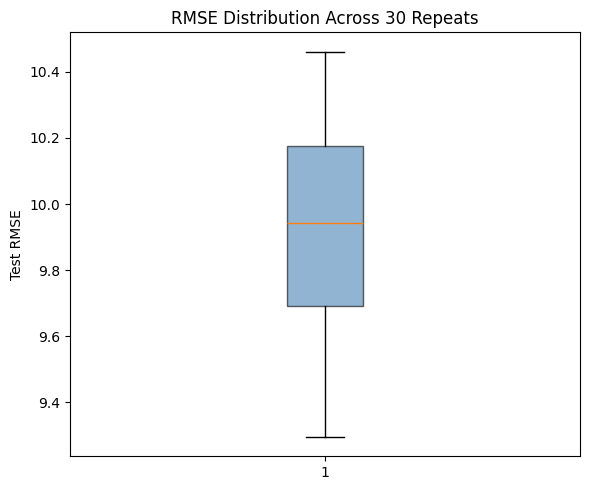

In [ ]:
# Boxplot of repeat RMSE distribution
results_df = pd.DataFrame({"rmse": error_scores})
print(results_df.describe().round(4))

plt.figure(figsize=(6, 5))
plt.boxplot(
    error_scores, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6)
)
plt.ylabel("Test RMSE")
plt.title(f"RMSE Distribution Across {Repeats} Repeats")
plt.tight_layout()
plt.show()

In [ ]:
# Test set actual values
test_actual = original_df[-len(test_scaled) :]

# Train predictions in original price scale
train_preds_original = []
n_train = len(train_scaled)
n_test = len(test_scaled)

for i in range(n_train):
    X = train_scaled[i, 0:-1]
    yhat = forecast_lstm(best_model, X)
    yhat = invert_scale(scaler, X, yhat)

    # -----------------------------------------------------------------
    # Anchor to the correct position in original_df for each train step
    # Position in original_df = i + 1 (one step ahead of current index)
    anchor_pos = len(original_df) - n_train - n_test + i
    yhat = original_df[anchor_pos] + yhat
    # -----------------------------------------------------------------

    train_preds_original.append(yhat)

train_actual = original_df[len(original_df) - n_train - n_test : len(original_df) - n_test]

In [ ]:
''' Both evaluated in original price scale '''
# Evaluate train set
train_metrics_lstm = evaluate_model(train_actual, train_preds_original, model_name="LSTM-Train")

# Evaluate test set
test_metrics_lstm = evaluate_model(test_actual, best_predictions, model_name="LSTM-Test")

LSTM-Train Performance:
MAE  : 0.7
RMSE : 0.89
MAPE : 1.53%
LSTM-Test Performance:
MAE  : 7.9
RMSE : 9.29
MAPE : 5.84%


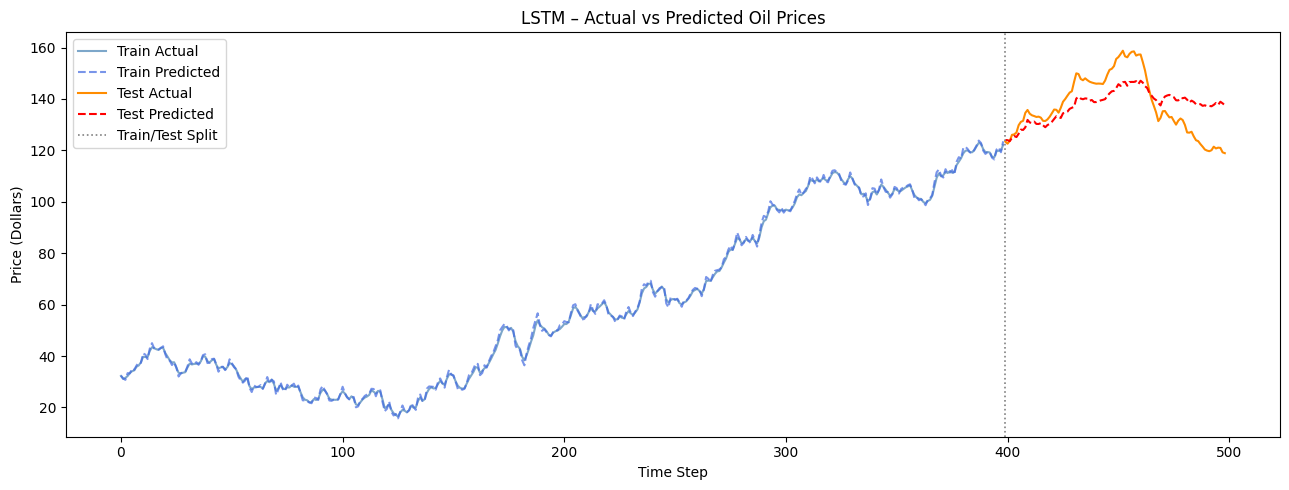

In [ ]:
''' Plot of Original train/test and predicted training/test '''

fig, ax = plt.subplots(figsize=(13, 5))

# Plot for original train
ax.plot(
    range(len(train_actual)),
    train_actual,
    label='Train Actual',
    color='steelblue',
    alpha=0.7,
)

# Plot for predicted train
ax.plot(
    range(len(train_actual)),
    train_preds_original,
    label='Train Predicted',
    color='royalblue',
    linestyle='--',
    alpha=0.7,
)

len_train_actual = len(train_actual)

# Plot for original test
ax.plot(
    range(len_train_actual, len_train_actual + len(test_actual)),
    test_actual,
    label='Test Actual',
    color='darkorange',
)

# Plot for predicted test
ax.plot(
    range(len_train_actual, len_train_actual + len(test_actual)),
    best_predictions,
    label='Test Predicted',
    color='red',
    linestyle='--',
)

# Line to show train and test split
ax.axvline(
    x=len_train_actual, color='grey', linestyle=':', linewidth=1.2, label='Train/Test Split'
)

# Plot properties
ax.set_title('LSTM – Actual vs Predicted Oil Prices')
ax.set_xlabel('Time Step')
ax.set_ylabel('Price (Dollars)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
np.round(best_predictions[0],2)

np.float64(124.04)

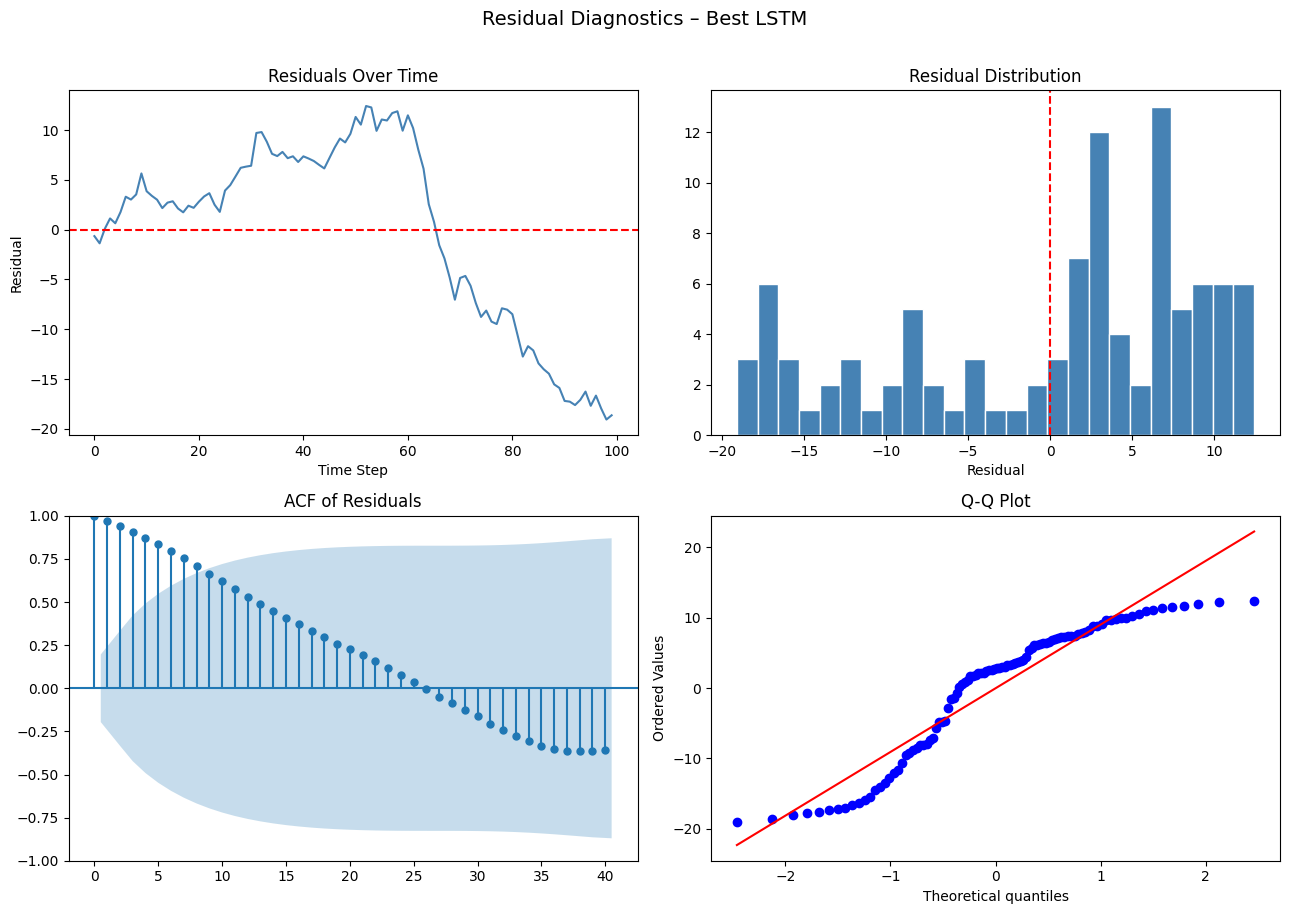

Residual mean : -0.0324  (ideal: 0)
Residual std  : 9.2941


In [ ]:
"""Residual diagnostics of the lstm model"""

# Get residual from original test values and predicted test values
residuals = test_actual - np.array(best_predictions)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Residuals over time
axes[0, 0].plot(residuals, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals Over Time")
axes[0, 0].set_xlabel("Time Step")
axes[0, 0].set_ylabel("Residual")

# Histogram
axes[0, 1].hist(residuals, bins=25, color="steelblue", edgecolor="white")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("Residual")

#  ACF (Corelogram)
plot_acf(residuals, lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Residuals")

# Q-Q Plot
probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.suptitle("Residual Diagnostics – Best LSTM", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Residual mean : {residuals.mean():.4f}  (ideal: 0)")
print(f"Residual std  : {residuals.std():.4f}")

In [ ]:
def forecast_future(model, diff_values, original_df, scaler, best_lag, n_steps):
    """
    A function to forecast the given number of days
    Forecasted days are then resampled to month-start to accomodate longer month
    """

    history_diff = list(diff_values.values)
    history_raw = list(original_df)
    future_preds = []

    # historical average
    historical_mean = np.mean(original_df)

    # Rebuild hidden state on all training data before forecasting
    supervised = timeseries_to_supervised(diff_values, best_lag)
    sup_vals = supervised.values
    split = int(len(sup_vals) * 0.8)
    train_full = sup_vals[:split]

    # Extract scaler dimension
    _, train_scaled_full, _ = scale(train_full, train_full)

    # Use the original scaler for scaling
    X_feed = sup_vals[:, 0:-1].reshape(len(sup_vals), 1, best_lag)

    # Scale feed input row-by-row using existing scaler
    X_feed_scaled = np.array(
        [
            scaler.transform(np.append(row, 0).reshape(1, -1))[0, 0:-1]
            for row in sup_vals[:, 0:-1]
        ]
    )

    X_feed_scaled = X_feed_scaled.reshape(len(X_feed_scaled), 1, best_lag)
    model.predict(X_feed_scaled.reshape(-1, 1, best_lag), batch_size=1, verbose=0)

    for step in range(n_steps):
        # Prepare input
        x_raw = np.array(history_diff[-best_lag:])
        dummy = np.append(x_raw, 0).reshape(1, -1)
        x_scaled = scaler.transform(dummy)[0, 0:-1]

        # Predict next difference
        yhat_scaled = forecast_lstm(model, x_scaled)
        yhat_diff = invert_scale(scaler, x_scaled, yhat_scaled)

        # This pulls the price back if it gets too far from the average
        # without needing to specify a maximum.
        current_price = history_raw[-1]
        deviation = current_price - historical_mean


        # Tp prevents price explosion
        pull_back = 0.01 * deviation
        yhat_diff = yhat_diff - pull_back

        # Construct the price
        yhat_raw = current_price + yhat_diff

        # Update history
        history_diff.append(yhat_diff)
        history_raw.append(yhat_raw)
        future_preds.append(yhat_raw)

    return future_preds

In [ ]:
forecast_days = 730

# Get future prices forecasted
future_prices_daily = forecast_future(
    best_model, diff_values, original_df, scaler, best_lag, n_steps=forecast_days
)

# Daily date index starting the day after the last observed date
last_date = oil_df.index[-1]
future_dates = future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq='D'
)
future_series = pd.Series(future_prices_daily, index=future_dates)

# Resample to monthly (first day of each month)
monthly_forecast_lstm = future_series.resample("MS").mean()
print(f"Monthly forecast ({len(monthly_forecast_lstm)} months):")
print(monthly_forecast_lstm.round(2).to_string())

Monthly forecast (25 months):
2026-02-01    112.06
2026-03-01    103.88
2026-04-01    107.04
2026-05-01    122.77
2026-06-01    139.63
2026-07-01    150.38
2026-08-01    156.24
2026-09-01    159.13
2026-10-01    159.90
2026-11-01    161.63
2026-12-01    168.85
2027-01-01    185.46
2027-02-01    204.57
2027-03-01    218.42
2027-04-01    226.95
2027-05-01    231.54
2027-06-01    234.04
2027-07-01    235.28
2027-08-01    235.63
2027-09-01    235.95
2027-10-01    236.13
2027-11-01    236.07
2027-12-01    235.99
2028-01-01    236.18
2028-02-01    236.09
Freq: MS


In [ ]:
"""
Growing CI: uncertainty increases with forecast time steps.
1.96 * residual_std * sqrt(time_steps) gives a 95% interval.
"""
residual_std = residuals.std()

daily_steps = np.arange(1, len(monthly_forecast_lstm) + 1)
time_steps = np.sqrt(daily_steps)

# Get the upper and lower limit  of confidence interval
ci_upper = monthly_forecast_lstm.values + 1.96 * residual_std * time_steps
ci_lower = monthly_forecast_lstm.values - 1.96 * residual_std * time_steps

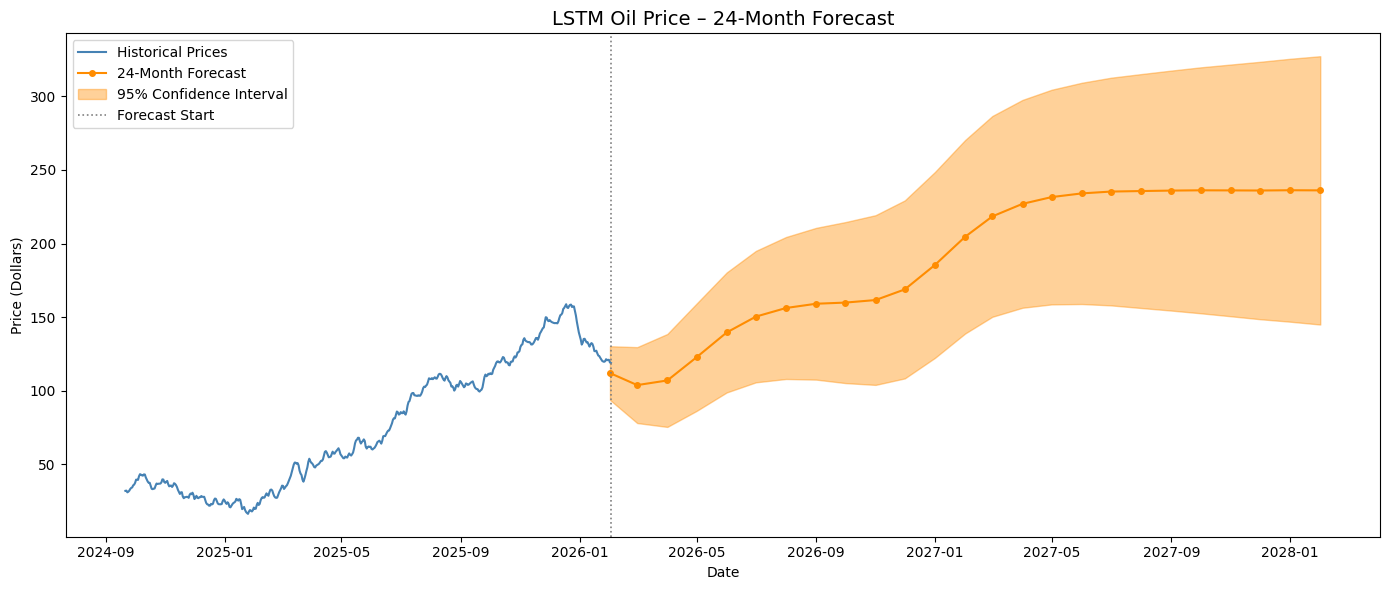

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical prices
history_window = oil_df['price']
ax.plot(history_window.index, history_window.values,
        color='steelblue', label='Historical Prices', linewidth=1.5)

# Monthly forecast
ax.plot(monthly_forecast_lstm.index, monthly_forecast_lstm.values,
        color='darkorange', label='24-Month Forecast', linewidth=1.5, marker='o',
        markersize=4)

# confidence interval
ax.fill_between(monthly_forecast_lstm.index, ci_lower, ci_upper,
                color='darkorange', alpha=0.4, label='95% Confidence Interval')

# Show point on plot when forecast started
ax.axvline(x=oil_df.index[-1], color='grey', linestyle=':', linewidth=1.2,
           label='Forecast Start')

# Plotr properties
ax.set_title('LSTM Oil Price – 24-Month Forecast', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (Dollars)')
ax.legend()
plt.tight_layout()
plt.show()


# **Model Performance Comparison**

In [ ]:
arima_test_metrics = {
    'Model': 'ARIMA - Test',
    'MAE': test_metrics['MAE'],
    'RMSE': test_metrics['RMSE'],
    'MAPE': test_metrics['MAPE']
}

lstm_test_metrics = {
    'Model': 'LSTM – Test',
    'MAE': test_metrics_lstm['MAE'],
    'RMSE': test_metrics_lstm['RMSE'],
    'MAPE': test_metrics_lstm['MAPE']
}

all_metrics = [arima_test_metrics, lstm_test_metrics]
performance_df = pd.DataFrame(all_metrics)

print("Performance Metrics on Test:")
print(performance_df)

Performance Metrics on Test:
          Model    MAE   RMSE   MAPE
0  ARIMA - Test  15.31  18.83  10.55
1   LSTM – Test   7.90   9.29   5.84


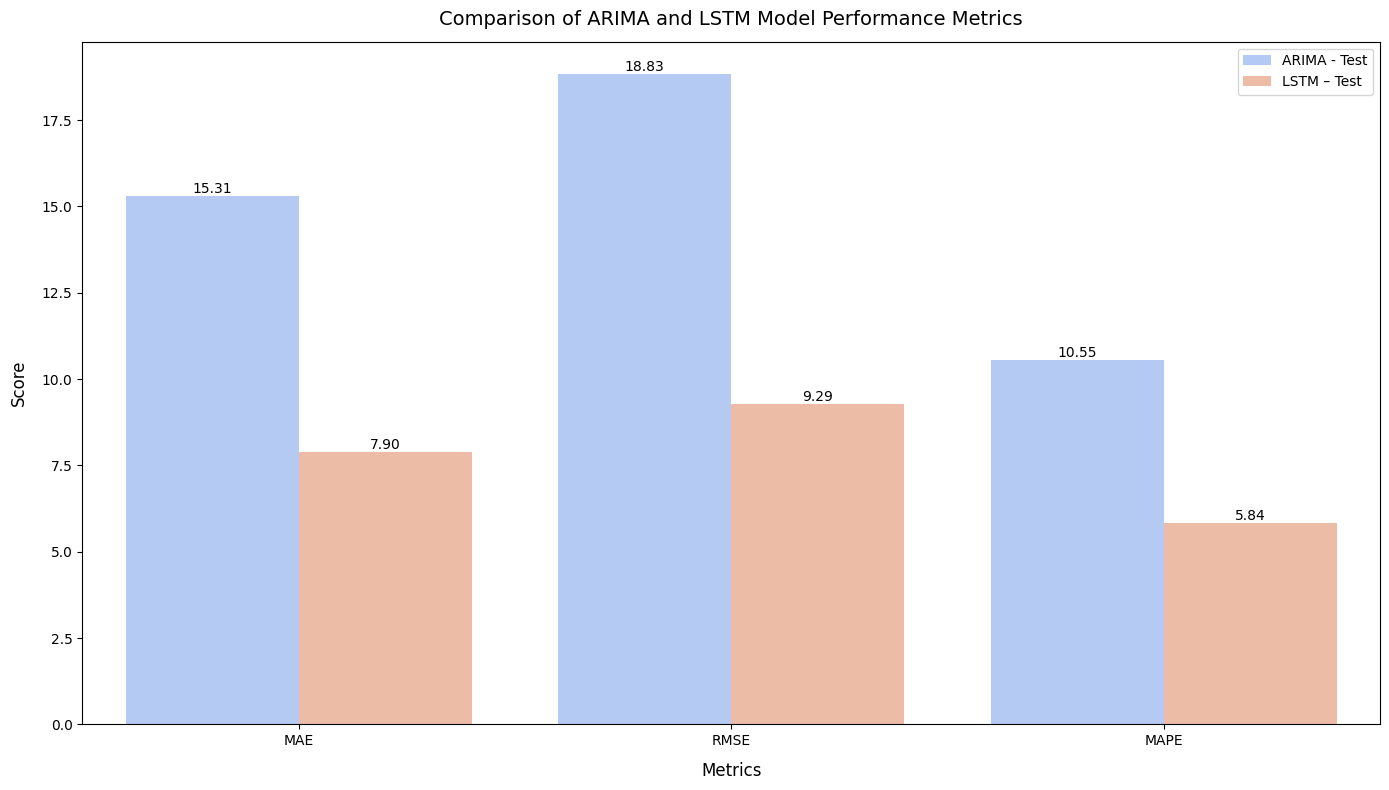

In [ ]:
performance_df_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Value', hue='Model', data=performance_df_melted, palette='coolwarm')
plt.title('Comparison of ARIMA and LSTM Model Performance Metrics', fontsize=14, pad=12)
plt.xlabel('Metrics', fontsize=12, labelpad=10)
plt.ylabel('Score', fontsize=12, labelpad=10)
plt.legend(loc='best')

# Show data values
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()